# Neural Style Transfer with PyTorch and VGG19

In this notebook, as part of the Convolutional Neural Networks (CNN) section, we will implement the Neural Style Transfer (NST) algorithm introduced by Gatys et al. The main objective is to blend the content of one image with the artistic style of another. We will use a pre-trained VGG19 network to extract image features at various levels of abstraction.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Device configuration (Supports Apple Silicon MPS, CUDA, and CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
print(f"Using device: {device}")

Using device: mps


### Image Preprocessing

In [2]:
def load_image(image_path, max_size=400, shape=None):
    """
    Loads an image and converts it to a tensor.
    """
    image = Image.open(image_path).convert('RGB')
    
    # Resize image if it is too large
    if max(image.size) > max_size:
        size = max_size
    else:
        size = max(image.size)
        
    if shape is not None:
        size = shape
        
    transform = transforms.Compose([
        transforms.Resize(size),
        transforms.ToTensor(),
        # Normalize based on ImageNet stats
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
    
    # Add batch dimension and move to device
    image = transform(image).unsqueeze(0)
    return image.to(device)

def im_convert(tensor):
    """
    Converts a tensor back to an image for visualization.
    """
    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze(0)
    image = image.transpose(1, 2, 0)
    
    # Denormalize
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)
    
    return image

### Loading the Model and Extracting Features

In [3]:
# Load pre-trained VGG19 model features
vgg = models.vgg19(weights='DEFAULT').features

# Freeze model parameters
for param in vgg.parameters():
    param.requires_grad = False

vgg.to(device)

def get_features(image, model, layers=None):
    """
    Run an image forward through a model and get the features for 
    a set of specific layers.
    """
    if layers is None:
        # Standard layer mappings for VGG19 in Style Transfer
        layers = {
            '0': 'conv1_1',
            '5': 'conv2_1',
            '10': 'conv3_1',
            '19': 'conv4_1',
            '21': 'conv4_2',  # Typically used for content representation
            '28': 'conv5_1'
        }
        
    features = {}
    x = image
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
            
    return features

def gram_matrix(tensor):
    """
    Calculate the Gram Matrix of a given tensor to capture style/texture.
    """
    _, d, h, w = tensor.size()
    tensor = tensor.view(d, h * w)
    gram = torch.mm(tensor, tensor.t())
    return gram

### Training Loop

In [4]:
def run_style_transfer(content_path, style_path, model, style_weights, 
                       content_weight=1, style_weight=1e6, lr=0.003, steps=2000, 
                       show_every=400, content_layer='conv4_2'):
    """
    Executes the Neural Style Transfer optimization loop.
    """
    print(f"--- Starting Style Transfer for: {style_path.split('/')[-1]} ---")
    
    # 1. Load images
    content_img = load_image(content_path)
    style_img = load_image(style_path, shape=content_img.shape[-2:])
    
    # 2. Extract features and calculate style Gram matrices
    content_features = get_features(content_img, model)
    style_features = get_features(style_img, model)
    style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}
    
    # 3. Initialize target image
    target_img = content_img.clone().requires_grad_(True).to(device)
    
    # 4. Setup Optimizer
    optimizer = optim.Adam([target_img], lr=lr)
    
    # 5. Training Loop
    for ii in range(1, steps + 1):
        target_features = get_features(target_img, model)
        
        # Calculate Content Loss
        content_loss = torch.mean((target_features[content_layer] - content_features[content_layer]) ** 2)
        
        # Calculate Style Loss
        style_loss = 0
        for layer in style_weights:
            target_feature = target_features[layer]
            target_gram = gram_matrix(target_feature)
            _, d, h, w = target_feature.shape
            style_gram = style_grams[layer]
            
            layer_style_loss = style_weights[layer] * torch.mean((target_gram - style_gram) ** 2)
            style_loss += layer_style_loss / (d * h * w)
            
        # Total Loss
        total_loss = content_weight * content_loss + style_weight * style_loss
        
        # Update target image
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        # Print statistics
        if ii % show_every == 0:
            print(f"Step [{ii}/{steps}] | Total Loss: {total_loss.item():.4f} | "
                  f"Content Loss: {content_loss.item():.4f} | Style Loss: {style_loss.item():.4f}")
            
    return content_img, style_img, target_img

### Visualization

In [5]:
def visualize_results(content_img, style_img, target_img, title="Neural Style Transfer"):
    """
    Plots the content, style, and stylized target images side-by-side.
    """
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    ax1.imshow(im_convert(content_img))
    ax1.set_title("Content Image")
    ax1.axis('off')

    ax2.imshow(im_convert(style_img))
    ax2.set_title("Style Image")
    ax2.axis('off')

    ax3.imshow(im_convert(target_img))
    ax3.set_title("Target Image (Style Transfer)")
    ax3.axis('off')

    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Composition VII Style Execution

--- Starting Style Transfer for: composition_vii.jpg ---
Step [400/2000] | Total Loss: 230369472.0000 | Content Loss: 16.4025 | Style Loss: 46.0739
Step [800/2000] | Total Loss: 79628024.0000 | Content Loss: 17.7642 | Style Loss: 15.9256
Step [1200/2000] | Total Loss: 41350424.0000 | Content Loss: 18.4716 | Style Loss: 8.2701
Step [1600/2000] | Total Loss: 26229504.0000 | Content Loss: 18.9453 | Style Loss: 5.2459
Step [2000/2000] | Total Loss: 18568630.0000 | Content Loss: 19.3063 | Style Loss: 3.7137


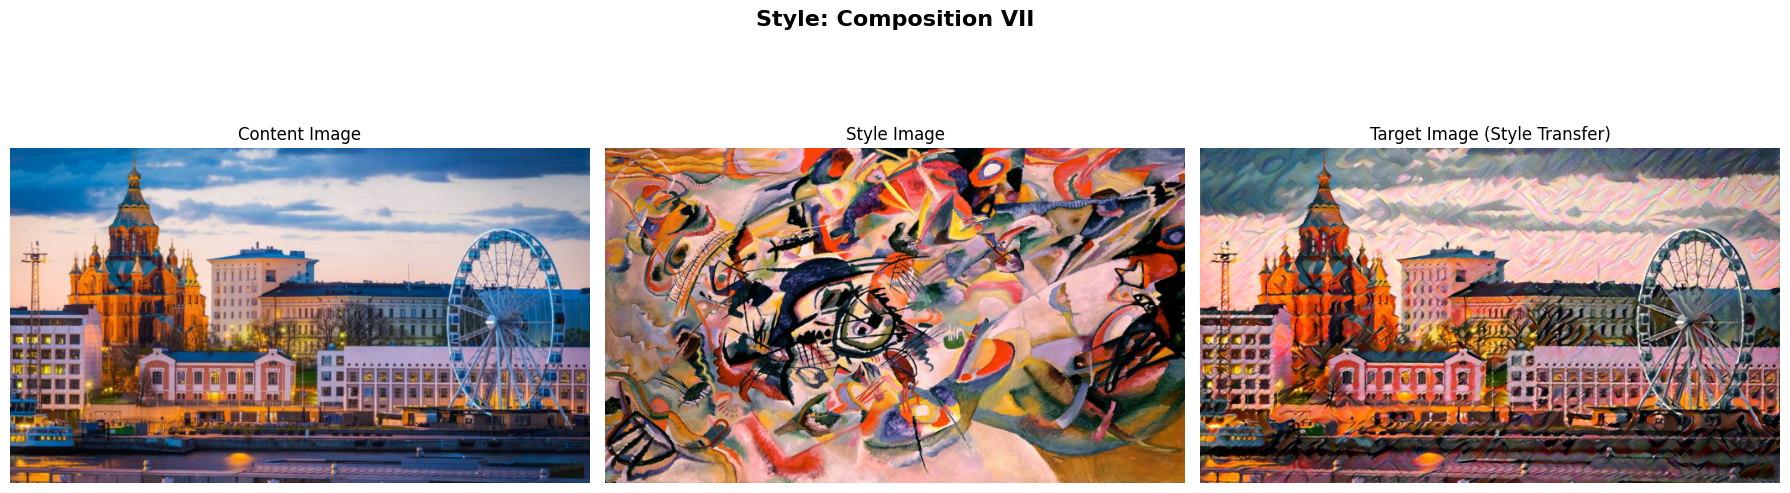

In [6]:
comp_vii_weights = {
    'conv1_1': 1.0,   
    'conv2_1': 0.8,   
    'conv3_1': 0.5,   
    'conv4_1': 0.3,
    'conv5_1': 0.1
}

c_img, s_img, t_img = run_style_transfer(
    content_path='dataset/Helsinki.jpg',
    style_path='dataset/styles/composition_vii.jpg',
    model=vgg,
    style_weights=comp_vii_weights,
    style_weight=5e6,
    lr=0.003
)

visualize_results(c_img, s_img, t_img, title="Style: Composition VII")

### The Starry Night Style Execution

--- Starting Style Transfer for: TheـStarryـNight.jpg ---
Step [400/2000] | Total Loss: 6494644224.0000 | Content Loss: 13.6734 | Style Loss: 6.4946
Step [800/2000] | Total Loss: 3127769856.0000 | Content Loss: 14.3591 | Style Loss: 3.1278
Step [1200/2000] | Total Loss: 1983471616.0000 | Content Loss: 14.6917 | Style Loss: 1.9835
Step [1600/2000] | Total Loss: 1375893632.0000 | Content Loss: 14.8971 | Style Loss: 1.3759
Step [2000/2000] | Total Loss: 996142336.0000 | Content Loss: 15.0575 | Style Loss: 0.9961


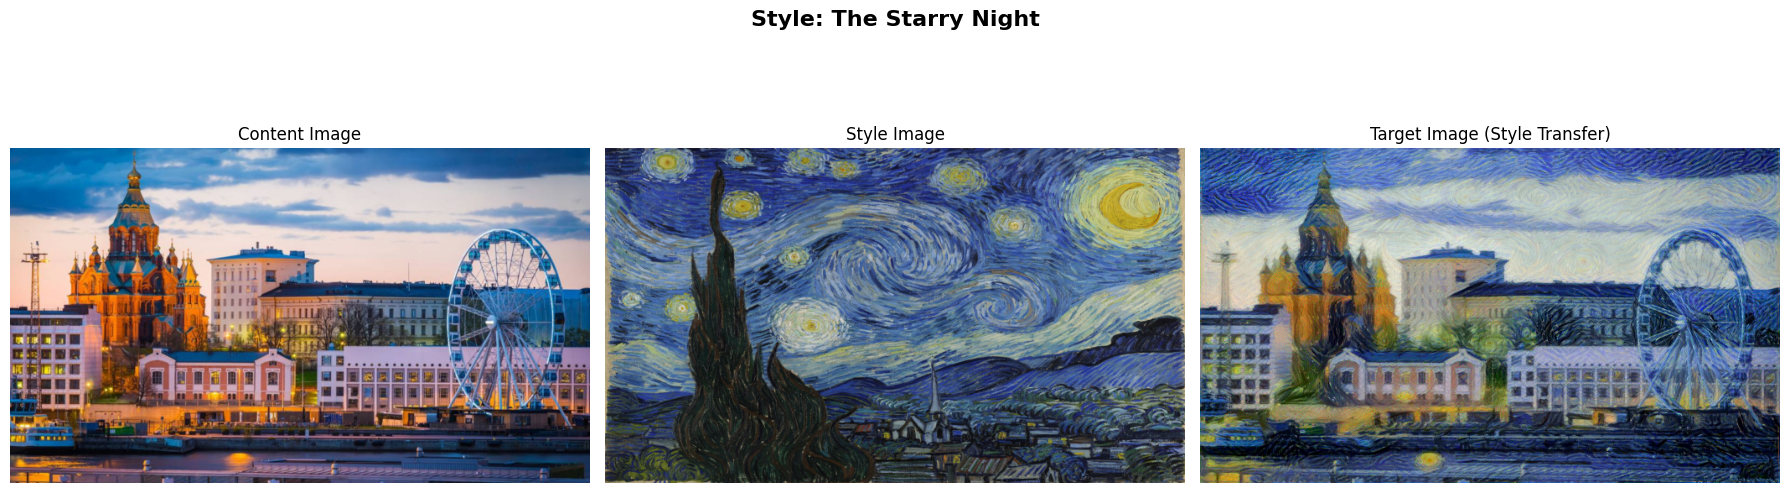

In [8]:
starry_weights = {
    'conv1_1': 1.0,   
    'conv2_1': 1.0,   
    'conv3_1': 1.0,   
    'conv4_1': 1.0,   
    'conv5_1': 1.0    
}

c_img_starry, s_img_starry, t_img_starry = run_style_transfer(
    content_path='dataset/Helsinki.jpg',
    style_path='dataset/styles/TheـStarryـNight.jpg',
    model=vgg,
    style_weights=starry_weights,
    style_weight=1e9,  # Higher weight for stronger style
    lr=0.01            # Higher learning rate for macro-structures
)

visualize_results(c_img_starry, s_img_starry, t_img_starry, title="Style: The Starry Night")